In [5]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["UNSLOTH_USE_FUSED_CROSS_ENTROPY"] = "0"

import unsloth
from unsloth import FastLanguageModel
import torch, gc
import matplotlib.pyplot as plt
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer

gc.collect()
torch.cuda.empty_cache()

# Config
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct"
DATASET_PATH = "csv/train.csv"
OUTPUT_DIR   = "./qwen-svg-lora"
MAX_SEQ_LEN  = 1024
BATCH_SIZE   = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"VRAM in use: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU: {torch.cuda.get_device_name(0)}")

VRAM in use: 0.00 GB
GPU: NVIDIA GeForce RTX 3090


In [6]:
SYSTEM_PROMPT = """You are an expert SVG coder. Generate valid, complete SVG code matching the user's description.
STRICT CONSTRAINTS:
1. Return ONLY raw SVG code. No markdown, no explanations.
2. Use only valid SVG elements. Never use <image>, <foreignObject>, or HTML tags.
3. Ensure all tags are properly closed and XML is well-formed."""

def format_example(example):
    return {"text": (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\nGenerate SVG for: {example['prompt']}<|im_end|>\n"
        f"<|im_start|>assistant\n{example['svg']}<|im_end|>"
    )}

print("Loading dataset...")
dataset = load_dataset("csv", data_files=DATASET_PATH, split="train")
dataset = dataset.filter(lambda x: x["prompt"] is not None and x["svg"] is not None)
dataset = dataset.map(format_example, remove_columns=dataset.column_names, num_proc=4)
print(f"✅ {len(dataset)} samples ready")
print(f"Sample:\n{dataset[0]['text'][:300]}...")

Loading dataset...
✅ 50000 samples ready
Sample:
<|im_start|>system
You are an expert SVG coder. Generate valid, complete SVG code matching the user's description.
STRICT CONSTRAINTS:
1. Return ONLY raw SVG code. No markdown, no explanations.
2. Use only valid SVG elements. Never use <image>, <foreignObject>, or HTML tags.
3. Ensure all tags are p...


In [7]:
gc.collect()
torch.cuda.empty_cache()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name          = MODEL_NAME,
    max_seq_length      = MAX_SEQ_LEN,
    load_in_4bit        = False,
    dtype               = torch.bfloat16,
    fast_inference      = False,
    attn_implementation = "sdpa",
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 32,
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = False,
    random_state   = 3407,
)

tokenizer.pad_token = tokenizer.eos_token
model.config.use_cache = False

allocated = torch.cuda.memory_allocated()/1024**3
print(f"✅ Model loaded | VRAM used: {allocated:.2f} GB | Free: {24-allocated:.2f} GB")
print(f"Device: {model.device} | Dtype: {model.dtype}")

==((====))==  Unsloth 2026.3.17: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 24.0 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.6. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.17 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


✅ Model loaded | VRAM used: 5.89 GB | Free: 18.11 GB
Device: cuda:0 | Dtype: torch.bfloat16


In [8]:
trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LEN,
    packing            = True,
    dataset_num_proc   = 4,
    args = SFTConfig(
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = 8,
        warmup_steps                = 50,
        num_train_epochs            = 1,
        learning_rate               = 2e-4,
        bf16                        = True,
        optim                       = "adamw_8bit",
        seed                        = 3407,
        output_dir                  = OUTPUT_DIR,
        dataloader_pin_memory       = False,
        dataloader_num_workers      = 0,
        gradient_checkpointing      = False,
        logging_steps               = 5,
        save_strategy               = "steps",
        save_steps                  = 200,
        save_total_limit            = 2,
        report_to                   = "none",
    ),
)

print("🚀 Training...")
trainer_stats = trainer.train()
print(f"✅ Done in {trainer_stats.metrics['train_runtime']/60:.1f} min")
print(f"Speed: {trainer_stats.metrics['train_samples_per_second']:.2f} samples/s")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
🚀 Training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 3,125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
5,1.300327
10,1.165149
15,0.989614
20,0.787619
25,0.659719
30,0.540752
35,0.535974
40,0.517712
45,0.508423
50,0.473708


✅ Done in 257.0 min
Speed: 3.24 samples/s


✅ LoRA adapter saved to ./qwen-svg-lora/lora_adapter
Found HuggingFace hub cache directory: /home/rohan/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 2 files from cache to `./qwen-svg-lora/full_model`: 100%|██████████| 2/2 [00:23<00:00, 11.56s/it]


Successfully copied all 2 files from cache to `./qwen-svg-lora/full_model`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:32<00:00, 16.24s/it]


Unsloth: Merge process complete. Saved to `/home/rohan/nyu_svg_contest/qwen-svg-lora/full_model`
✅ Merged model saved to ./qwen-svg-lora/full_model


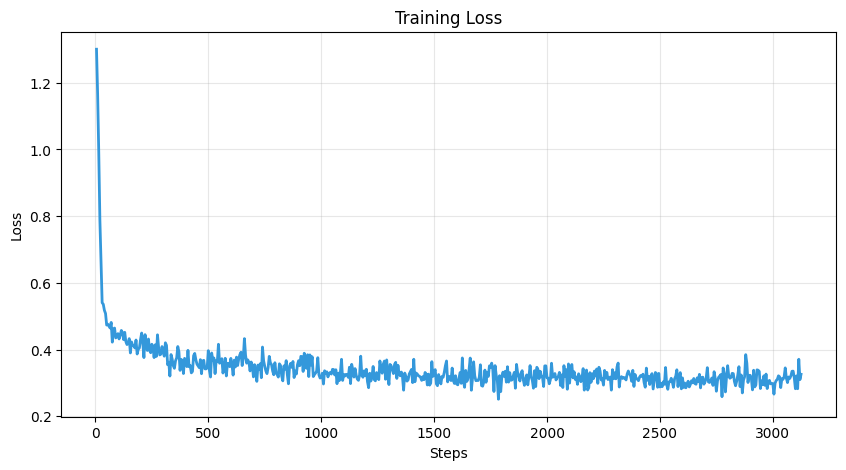

✅ Loss chart saved


In [9]:
# Save LoRA adapter (fast, ~40MB)
adapter_path = os.path.join(OUTPUT_DIR, "lora_adapter")
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"✅ LoRA adapter saved to {adapter_path}")

# Save full merged model for submission
merged_path = os.path.join(OUTPUT_DIR, "full_model")
model.save_pretrained_merged(merged_path, tokenizer, save_method="merged_16bit")
print(f"✅ Merged model saved to {merged_path}")

# Loss plot
logs   = trainer.state.log_history
steps  = [l["step"] for l in logs if "loss" in l]
losses = [l["loss"]  for l in logs if "loss" in l]

if steps:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, color="#3498db", linewidth=2)
    plt.title("Training Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_chart.png"))
    plt.show()
    print(f"✅ Loss chart saved")

In [15]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load clean base model
base_model = AutoModelForCausalLM.from_pretrained(
    "unsloth/Qwen2.5-3B-Instruct",
    torch_dtype=torch.bfloat16,
).to("cuda")

# Load your trained LoRA adapter on top
inf_model = PeftModel.from_pretrained(base_model, "./qwen-svg-lora/lora_adapter")
inf_model.eval()

inf_tokenizer = AutoTokenizer.from_pretrained("unsloth/Qwen2.5-3B-Instruct")

prompt = """<|im_start|>system
You are an expert SVG coder. Return ONLY raw SVG code.<|im_end|>
<|im_start|>user
Generate SVG for: A simple red circle on a white background.<|im_end|>
<|im_start|>assistant
"""

inputs = inf_tokenizer(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = inf_model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=0.7,
        do_sample=True,
    )

print(inf_tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True))

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AttributeError: 'Qwen2Attention' object has no attribute 'apply_qkv'

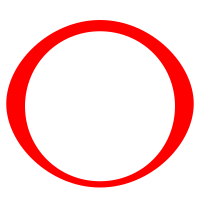

In [16]:
# In notebook - render the SVG
from IPython.display import SVG, display

svg_output = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF0000" fill-opacity="1.0"  filling="0" d="M100.0 187.5 C49.375 187.5 6.25 144.375 6.25 103.75 C6.25 63.125 49.375 20.0 100.0 20.0 C150.625 20.0 193.75 63.125 193.75 103.75 C193.75 144.375 150.625 187.5 100.0 187.5 Z M100.0 31.25 C58.125 31.25 25.0 64.375 25.0 106.25 C25.0 148.125 58.125 181.25 100.0 181.25 C141.875 181.25 175.0 148.125 175.0 106.25 C175.0 64.375 141.875 31.25 100.0 31.25 Z"></path></svg>'

display(SVG(svg_output))